In [1]:
import numpy as np
import pandas as pd
import scipy.io
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt


In [2]:
batteries = {}
battery_names = ['B0005', 'B0006', 'B0007', 'B0018']

for name in battery_names:
    data = scipy.io.loadmat(f'../data/raw/{name}.mat')
    batteries[name] = data[name]['cycle'][0][0][0]
    
print("Loaded batteries:", list(batteries.keys()))
print("Cycles in B0005:", batteries['B0005'].shape[0])
print("Cycles in B0006:", batteries['B0006'].shape[0])
print("Cycles in B0007:", batteries['B0007'].shape[0])
print("Cycles in B0018:", batteries['B0018'].shape[0])

Loaded batteries: ['B0005', 'B0006', 'B0007', 'B0018']
Cycles in B0005: 616
Cycles in B0006: 616
Cycles in B0007: 616
Cycles in B0018: 319


In [3]:
def extract_soh(cycles):
    discharge_capacities = []
    
    for i in range(cycles.shape[0]):
        cycle = cycles[i]
        if cycle['type'][0] == 'discharge':
            current = cycle['data'][0]['Current_measured'][0][0]
            time = cycle['data'][0]['Time'][0][0]
            capacity = np.trapezoid(abs(current), time) / 3600
            discharge_capacities.append(capacity)
    
    initial = discharge_capacities[0]
    soh = [cap / initial * 100 for cap in discharge_capacities]
    return np.array(soh)

soh_data = {}
for name in battery_names:
    soh_data[name] = extract_soh(batteries[name])
    print(f"{name}: {len(soh_data[name])} discharge cycles, final SOH: {soh_data[name][-1]:.2f}%")

B0005: 168 discharge cycles, final SOH: 71.31%
B0006: 168 discharge cycles, final SOH: 58.86%
B0007: 168 discharge cycles, final SOH: 75.90%
B0018: 132 discharge cycles, final SOH: 72.82%


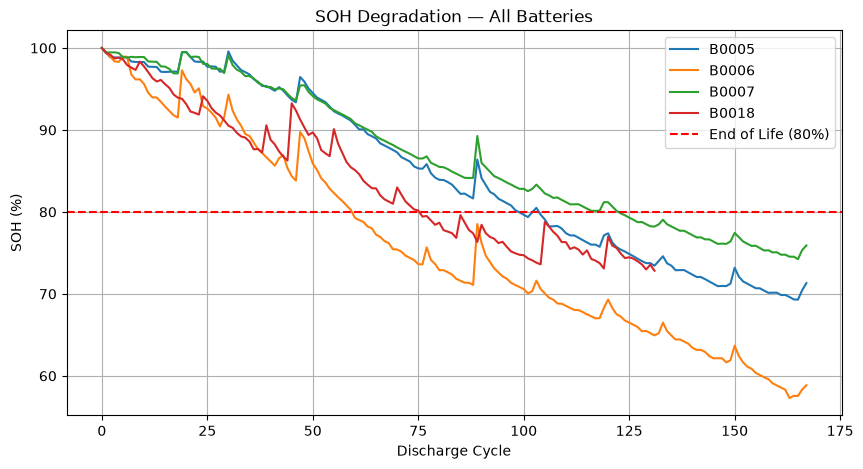

In [4]:
plt.figure(figsize=(10, 5))
for name in battery_names:
    plt.plot(soh_data[name], label=name)
plt.axhline(y=80, color='red', linestyle='--', label='End of Life (80%)')
plt.xlabel('Discharge Cycle')
plt.ylabel('SOH (%)')
plt.title('SOH Degradation — All Batteries')
plt.legend()
plt.grid(True)
plt.show()

In [5]:
def create_sequences(soh, look_back=10):
    X, y = [], []
    for i in range(len(soh) - look_back):
        X.append(soh[i : i + look_back]) 
        y.append(soh[i + look_back])      
    return np.array(X), np.array(y)


sequences = {}
for name in battery_names:
    X, y = create_sequences(soh_data[name])
    sequences[name] = (X, y)
    print(f"{name} — X shape: {X.shape}, y shape: {y.shape}")

B0005 — X shape: (158, 10), y shape: (158,)
B0006 — X shape: (158, 10), y shape: (158,)
B0007 — X shape: (158, 10), y shape: (158,)
B0018 — X shape: (122, 10), y shape: (122,)


In [6]:
# train on B0005, B0006, B0007 — test on B0018
X_train = np.concatenate([sequences['B0005'][0], sequences['B0006'][0], sequences['B0007'][0]])
y_train = np.concatenate([sequences['B0005'][1], sequences['B0006'][1], sequences['B0007'][1]])

X_test = sequences['B0018'][0]
y_test = sequences['B0018'][1]

print(f"Training samples: {X_train.shape}")
print(f"Testing samples: {X_test.shape}")

Training samples: (474, 10)
Testing samples: (122, 10)


In [7]:
scaler = MinMaxScaler()


X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


y_scaler = MinMaxScaler()
y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1))
y_test_scaled = y_scaler.transform(y_test.reshape(-1, 1))

print(f"X_train range: {X_train_scaled.min():.2f} to {X_train_scaled.max():.2f}")
print(f"X_test range: {X_test_scaled.min():.2f} to {X_test_scaled.max():.2f}")

X_train range: 0.00 to 1.00
X_test range: 0.33 to 1.00


In [8]:
X_train_lstm = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_lstm = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

print(f"X_train_lstm shape: {X_train_lstm.shape}")
print(f"X_test_lstm shape: {X_test_lstm.shape}")

X_train_lstm shape: (474, 10, 1)
X_test_lstm shape: (122, 10, 1)


In [9]:
np.save('../data/processed/X_train.npy', X_train_lstm)
np.save('../data/processed/X_test.npy', X_test_lstm)
np.save('../data/processed/y_train.npy', y_train_scaled)
np.save('../data/processed/y_test.npy', y_test_scaled)

print("Data saved successfully")

Data saved successfully
